In [29]:
import pandas as pd

In [30]:
df = pd.read_excel('/content/Online Retail.xlsx')

In [31]:
!find / -name "Online Retail.xlsx" 2>/dev/null

/content/Online Retail.xlsx
/Online Retail.xlsx


In [32]:
df = pd.read_excel('/Online Retail.xlsx')

In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [33]:
df.shape

(541909, 8)

In [34]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [27]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [28]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [36]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


In [37]:
df.duplicated().sum()

np.int64(5268)

In [38]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(9288)

In [39]:
cancellation_percentage = (
    df['InvoiceNo'].astype(str).str.startswith('C').sum()
    / len(df)
) * 100

print("Cancellation percentage:", cancellation_percentage)

Cancellation percentage: 1.7139409015166756


In [40]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [41]:
(df['UnitPrice'] < 0).sum()

np.int64(2)

In [42]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [43]:
(df['UnitPrice'] == 0).sum()

np.int64(2515)

In [44]:
df[df['UnitPrice'] == 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [45]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [46]:
print("Earliest date:", df['InvoiceDate'].min())
print("Latest date:", df['InvoiceDate'].max())

Earliest date: 2010-12-01 08:26:00
Latest date: 2011-12-09 12:50:00


In [47]:
df['Country'].nunique()

38

In [48]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [49]:
df['StockCode'].nunique()

4070

In [50]:
df['CustomerID'].nunique()

4372

In [51]:
df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [52]:
df['Description'].value_counts().head(10)

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2369
REGENCY CAKESTAND 3 TIER,2200
JUMBO BAG RED RETROSPOT,2159
PARTY BUNTING,1727
LUNCH BAG RED RETROSPOT,1638
ASSORTED COLOUR BIRD ORNAMENT,1501
SET OF 3 CAKE TINS PANTRY DESIGN,1473
PACK OF 72 RETROSPOT CAKE CASES,1385
LUNCH BAG BLACK SKULL.,1350


In [53]:
id="q5u7mx"
df['Quantity'].describe()

,Quantity
count,541909.000000
mean,9.552250
std,218.081158
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


In [55]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Quantity'])

plt.title('Quantity Distribution and Outliers')
plt.xlabel('Quantity')

plt.show()

NameError: name 'plt' is not defined

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

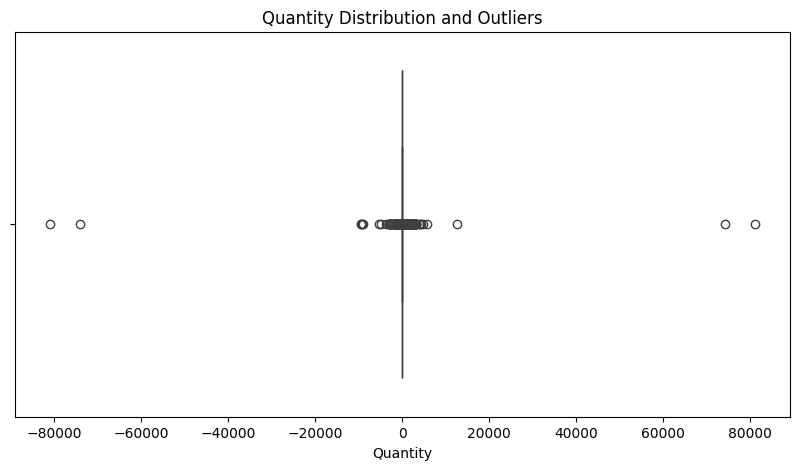

In [57]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Quantity'])

plt.title('Quantity Distribution and Outliers')
plt.xlabel('Quantity')

plt.show()

In [58]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 1.0
Q3: 10.0
IQR: 9.0
Lower Bound: -12.5
Upper Bound: 23.5


In [59]:
outliers = df[
    (df['Quantity'] < lower_bound) |
    (df['Quantity'] > upper_bound)
]

print("Number of Quantity outliers:", len(outliers))

Number of Quantity outliers: 58619


In [60]:
df.nlargest(10, 'Quantity')[[
    'InvoiceNo',
    'StockCode',
    'Description',
    'Quantity',
    'UnitPrice',
    'CustomerID',
    'Country'
]]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,13256.0,United Kingdom
74614,542504,37413,NaN,5568,0.00,NaN,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,13135.0,United Kingdom
220843,556231,85123A,?,4000,0.00,NaN,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,14609.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,United Kingdom


In [61]:
df.sort_values('Quantity').head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
225529,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
225530,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom
225528,556687,23003,Printing smudges/thrown away,-9058,2011-06-14 10:36:00,0.00,NaN,United Kingdom
115818,546152,72140F,throw away,-5368,2011-03-09 17:25:00,0.00,NaN,United Kingdom
431381,573596,79323W,"Unsaleable, destroyed.",-4830,2011-10-31 15:17:00,0.00,NaN,United Kingdom
341601,566768,16045,NaN,-3667,2011-09-14 17:53:00,0.00,NaN,United Kingdom
323458,565304,16259,NaN,-3167,2011-09-02 12:18:00,0.00,NaN,United Kingdom


In [63]:
df['Description'].isnull().sum()

np.int64(1454)

In [62]:
df['CustomerID'].isnull().sum()

np.int64(135080)

In [64]:
duplicate_percentage = (df.duplicated().sum() / len(df)) * 100

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate percentage:", duplicate_percentage)

Duplicate rows: 5268
Duplicate percentage: 0.9721189350979592


In [65]:
blank_descriptions = df['Description'].astype(str).str.strip().eq('').sum()

print("Blank descriptions:", blank_descriptions)

Blank descriptions: 0


In [66]:
df['InvoiceNo'].nunique()

25900

In [67]:
df['InvoiceNo'].isnull().sum()


np.int64(0)

In [68]:
df['StockCode'].isnull().sum()

np.int64(0)

In [70]:
df['Quantity'].isnull().sum()

np.int64(0)

In [69]:
df['InvoiceDate'].isnull().sum()

np.int64(0)

In [71]:
df['UnitPrice'].isnull().sum()

np.int64(0)

In [72]:
df['Country'].isnull().sum()

np.int64(0)

In [73]:
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Percentage
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [74]:
df_clean = df.copy()

print("Original dataset:", df.shape)
print("Cleaning copy:", df_clean.shape)

Original dataset: (541909, 8)
Cleaning copy: (541909, 8)


In [75]:
df_clean = df_clean.drop_duplicates()

print("Rows after removing duplicates:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Rows after removing duplicates: 536641
Rows removed: 5268


In [76]:
before = len(df_clean)

df_clean = df_clean.dropna(subset=['Description'])

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 536641
Rows after: 535187
Rows removed: 1454


In [77]:
before = len(df_clean)

df_clean = df_clean.dropna(subset=['Description'])

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 535187
Rows after: 535187
Rows removed: 0


In [78]:
df_clean['Description'].isnull().sum()

np.int64(0)

In [79]:
df_clean['CustomerID'].isnull().sum()

np.int64(133583)

In [80]:
before = len(df_clean)

df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Cancellation rows removed:", before - after)

Rows before: 535187
Rows after: 525936
Cancellation rows removed: 9251


In [81]:
negative_quantity_remaining = (df_clean['Quantity'] < 0).sum()

print("Negative quantities remaining:", negative_quantity_remaining)

Negative quantities remaining: 474


In [82]:
df_clean[df_clean['Quantity'] < 0][[
    'InvoiceNo',
    'StockCode',
    'Description',
    'Quantity',
    'UnitPrice',
    'CustomerID',
    'Country'
]].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
7313,537032,21275,?,-30,0.0,NaN,United Kingdom
13217,537425,84968F,check,-20,0.0,NaN,United Kingdom
13218,537426,84968E,check,-35,0.0,NaN,United Kingdom
13264,537432,35833G,damages,-43,0.0,NaN,United Kingdom
21338,538072,22423,faulty,-13,0.0,NaN,United Kingdom
21518,538090,20956,?,-723,0.0,NaN,United Kingdom
22296,538161,46000S,Dotcom sales,-100,0.0,NaN,United Kingdom
22297,538162,46000M,Dotcom sales,-100,0.0,NaN,United Kingdom
42564,540010,22501,reverse 21/5/10 adjustment,-100,0.0,NaN,United Kingdom
42566,540012,22502,reverse 21/5/10 adjustment,-100,0.0,NaN,United Kingdom


In [83]:
before = len(df_clean)

df_clean = df_clean[df_clean['Quantity'] > 0]

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 525936
Rows after: 525462
Rows removed: 474


In [84]:
before = len(df_clean)

df_clean = df_clean[df_clean['UnitPrice'] > 0]

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 525462
Rows after: 524878
Rows removed: 584


In [85]:
df_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,132186
Country,0


In [86]:
df_clean.duplicated().sum()

np.int64(0)

In [87]:
print("Negative Quantity:", (df_clean['Quantity'] < 0).sum())
print("Zero/Negative UnitPrice:", (df_clean['UnitPrice'] <= 0).sum())

Negative Quantity: 0
Zero/Negative UnitPrice: 0


In [88]:
df_clean.shape

(524878, 8)

In [89]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,524878.000000,524878,524878.000000,392692.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,156.280031,NaN,36.093028,1713.539549


In [90]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [91]:
df_clean.shape

(524878, 9)

In [92]:
df_clean.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')

In [93]:
df_clean.to_csv('cleaned_online_retail.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [94]:
import os

print("File exists:", os.path.exists('cleaned_online_retail.csv'))
print("File size (KB):", round(os.path.getsize('cleaned_online_retail.csv') / 1024, 2))

File exists: True
File size (KB): 49159.04


In [95]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [96]:
total_sales = df_clean['TotalAmount'].sum()

print("Total Sales Amount:", round(total_sales, 2))

Total Sales Amount: 10642110.8


In [97]:
unique_customers = df_clean['CustomerID'].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 4338


In [98]:
unique_products = df_clean['StockCode'].nunique()

print("Unique Products:", unique_products)

Unique Products: 3922


In [99]:
unique_countries = df_clean['Country'].nunique()

print("Unique Countries:", unique_countries)

Unique Countries: 38


In [100]:
top_countries = df_clean['Country'].value_counts().head(10)

print(top_countries)

Country
United Kingdom    479985
Germany             9025
France              8392
EIRE                7879
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1958
Portugal            1492
Australia           1181
Name: count, dtype: int64


In [101]:
top_products = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


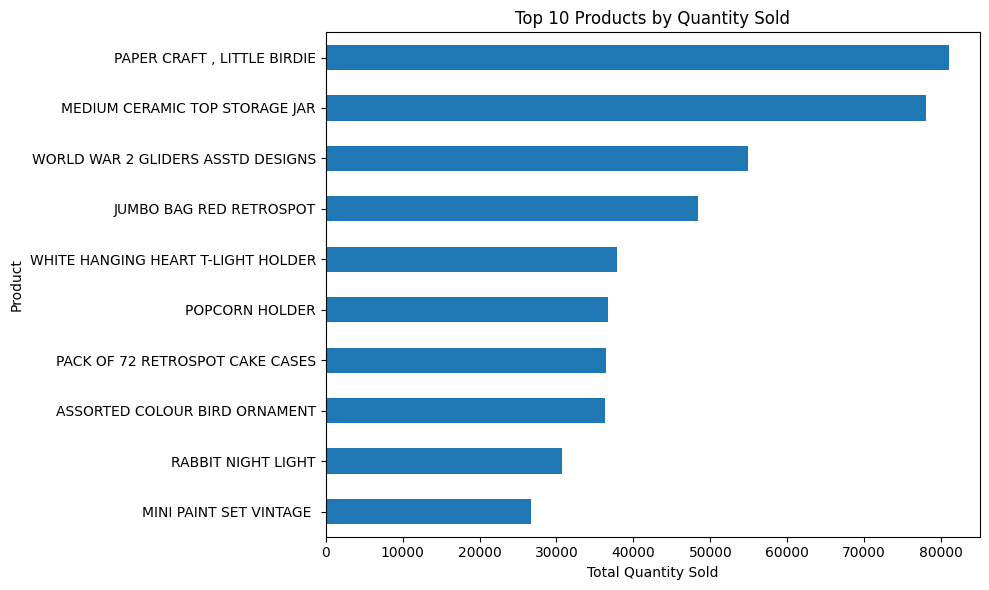

In [102]:
top_products.sort_values().plot(kind='barh', figsize=(10, 6))

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [103]:
top_sales_countries = (
    df_clean.groupby('Country')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_sales_countries)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64


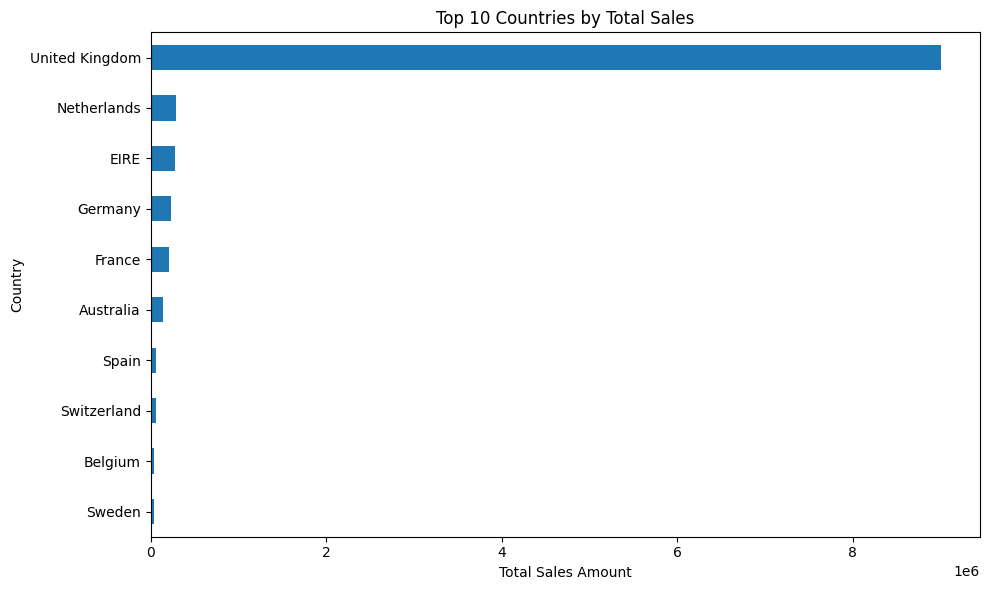

In [104]:
top_sales_countries.sort_values().plot(kind='barh', figsize=(10, 6))

plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Total Sales Amount')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [105]:
df_clean.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object
TotalAmount,float64


In [106]:
df_clean.to_csv('cleaned_online_retail.csv', index=False)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [107]:
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Rows: 524878
Columns: 9
Missing values: 132186
Duplicate rows: 0


In [ ]:
df_clean.isnull().sum()

In [108]:
print("FINAL DATASET SUMMARY")
print("---------------------")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Duplicate rows:", df_clean.duplicated().sum())
print("Missing CustomerID:", df_clean['CustomerID'].isnull().sum())
print("Negative Quantity:", (df_clean['Quantity'] < 0).sum())
print("Non-positive UnitPrice:", (df_clean['UnitPrice'] <= 0).sum())
print("Unique Customers:", df_clean['CustomerID'].nunique())
print("Unique Products:", df_clean['StockCode'].nunique())
print("Unique Countries:", df_clean['Country'].nunique())
print("Total Sales:", round(df_clean['TotalAmount'].sum(), 2))

FINAL DATASET SUMMARY
---------------------
Rows: 524878
Columns: 9
Duplicate rows: 0
Missing CustomerID: 132186
Negative Quantity: 0
Non-positive UnitPrice: 0
Unique Customers: 4338
Unique Products: 3922
Unique Countries: 38
Total Sales: 10642110.8


In [109]:
print("BEFORE vs AFTER CLEANING")
print("------------------------")
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))
print("Original columns:", len(df.columns))
print("Final columns:", len(df_clean.columns))

BEFORE vs AFTER CLEANING
------------------------
Original rows: 541909
Cleaned rows: 524878
Rows removed: 17031
Original columns: 8
Final columns: 9


In [110]:
from google.colab import files

files.download('cleaned_online_retail.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

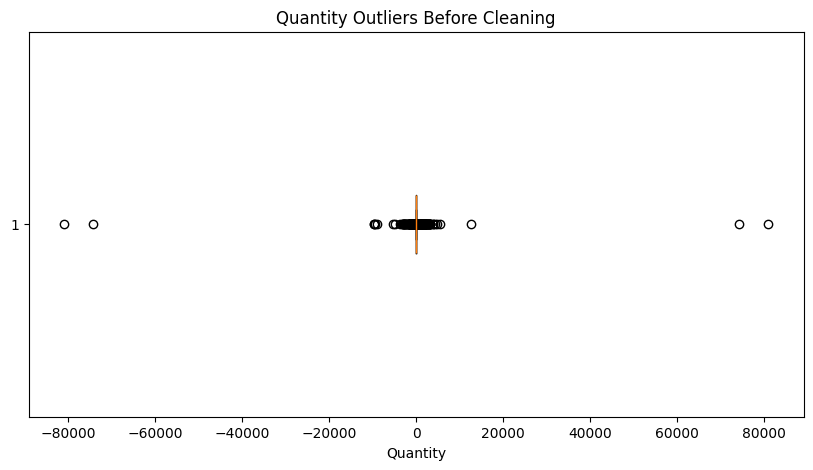

In [111]:
plt.figure(figsize=(10, 5))

plt.boxplot(df['Quantity'], vert=False)

plt.title('Quantity Outliers Before Cleaning')
plt.xlabel('Quantity')

plt.show()

In [116]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [114]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [113]:
df.duplicated().sum()

np.int64(5268)

In [117]:
print("BEFORE vs AFTER CLEANING")
print("------------------------")
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))
print("Original columns:", len(df.columns))
print("Final columns:", len(df_clean.columns))

BEFORE vs AFTER CLEANING
------------------------
Original rows: 541909
Cleaned rows: 524878
Rows removed: 17031
Original columns: 8
Final columns: 9


In [118]:
df_clean.shape

(524878, 9)

In [120]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,524878.000000,524878,524878.000000,392692.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865,20.275399
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,156.280031,NaN,36.093028,1713.539549,271.693566


In [121]:
country_sales = df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)

country_sales.head(10)

,TotalAmount
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


DESCRIPTIVE STATISTICS


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,524878.000000,524878,524878.000000,392692.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865,20.275399
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,156.280031,NaN,36.093028,1713.539549,271.693566



TOP 10 COUNTRIES BY TOTAL SALES


,TotalAmount
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


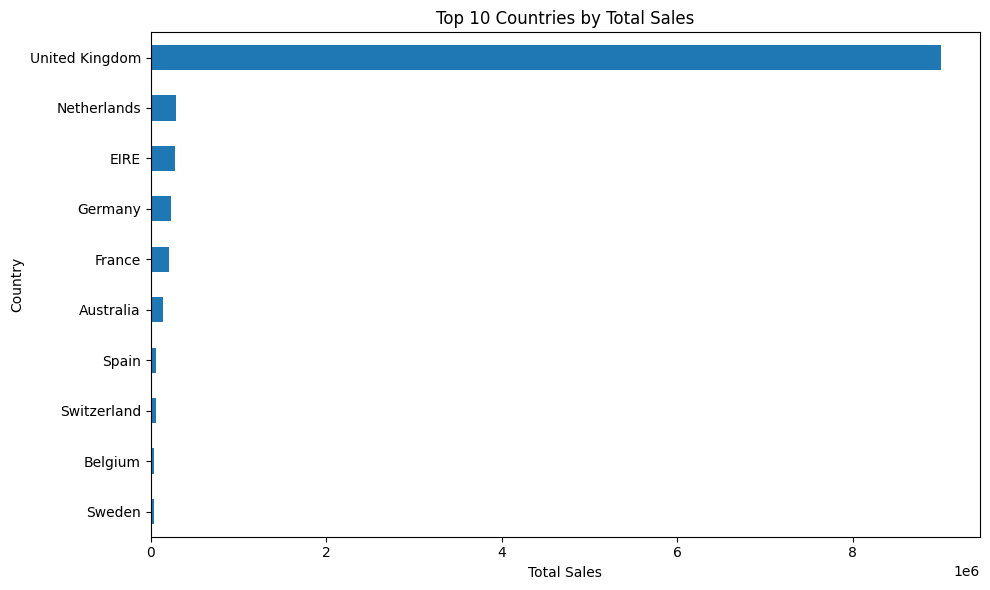


MONTHLY SALES


,TotalAmount
InvoiceDate,
2010-12-31,821452.730
2011-01-31,689811.610
2011-02-28,522545.560
2011-03-31,716215.260
2011-04-30,536968.491
2011-05-31,769296.610
2011-06-30,760547.010
2011-07-31,718076.121
2011-08-31,757841.380


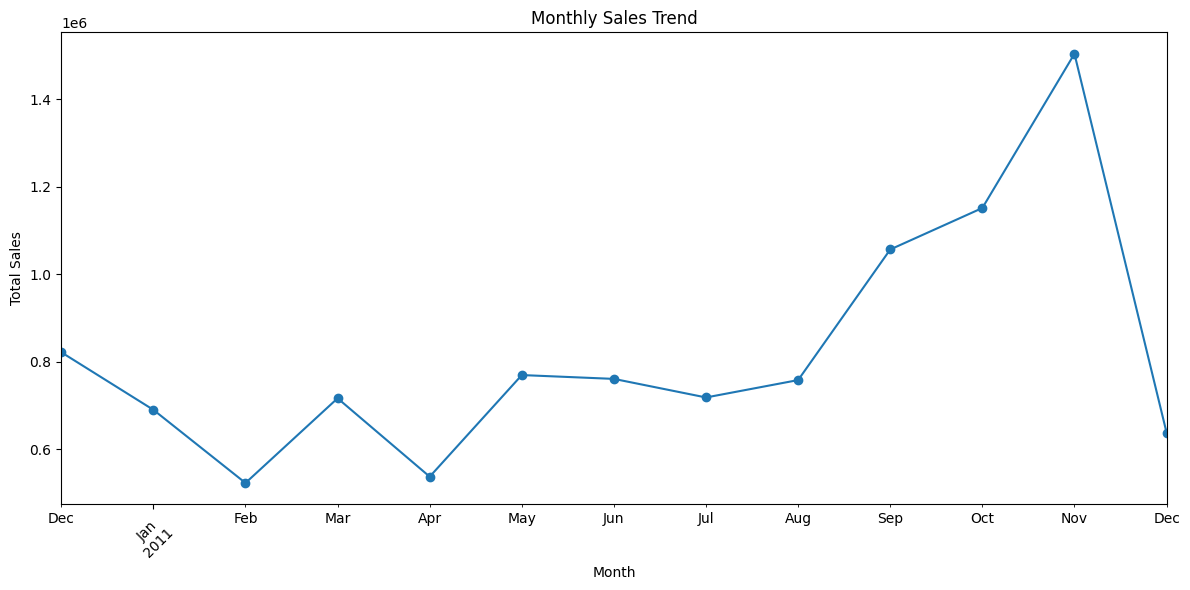


TOP 10 PRODUCTS BY TOTAL SALES


,TotalAmount
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


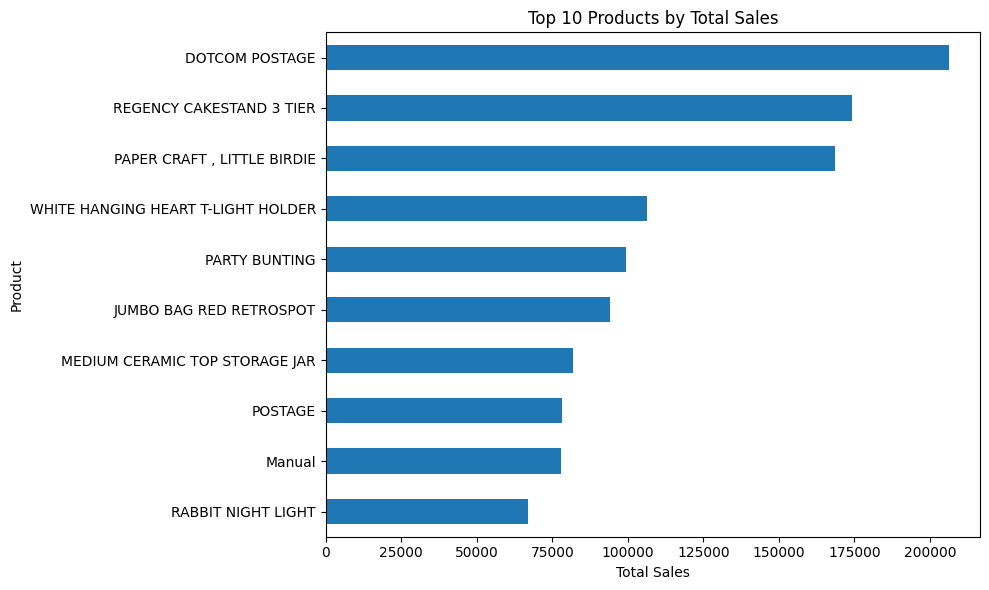


TOP 10 PRODUCTS BY QUANTITY SOLD


,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


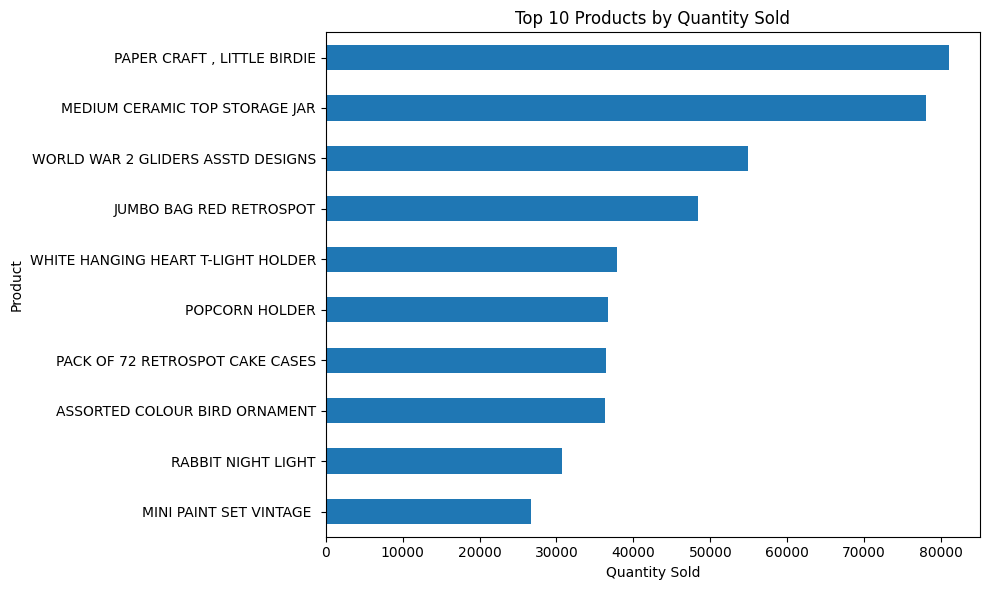

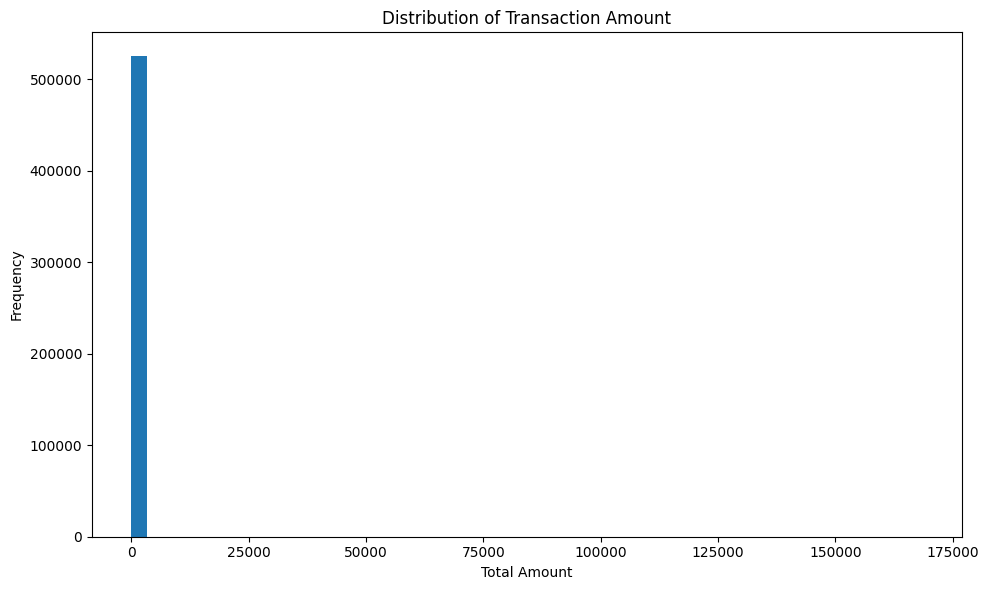

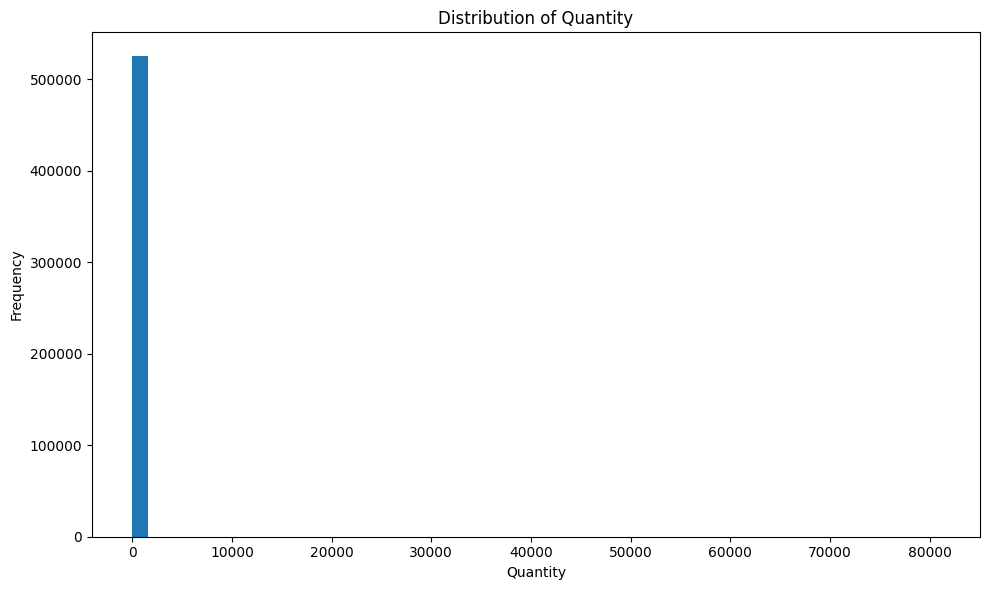


TOP 10 CUSTOMERS BY TOTAL SPENDING


,TotalAmount
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


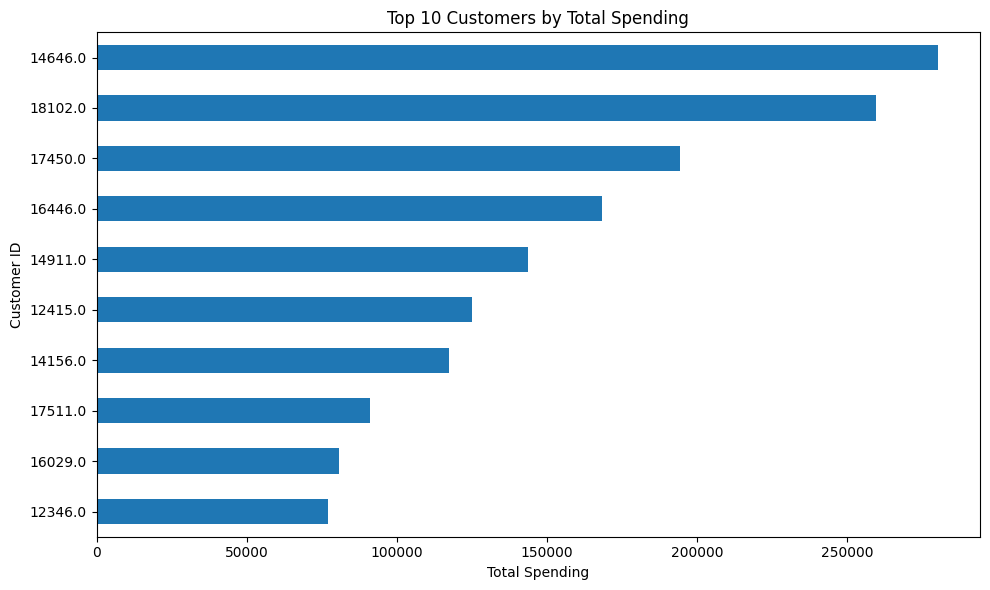


CORRELATION MATRIX


,Quantity,UnitPrice,TotalAmount
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
TotalAmount,0.907402,0.137381,1.000000


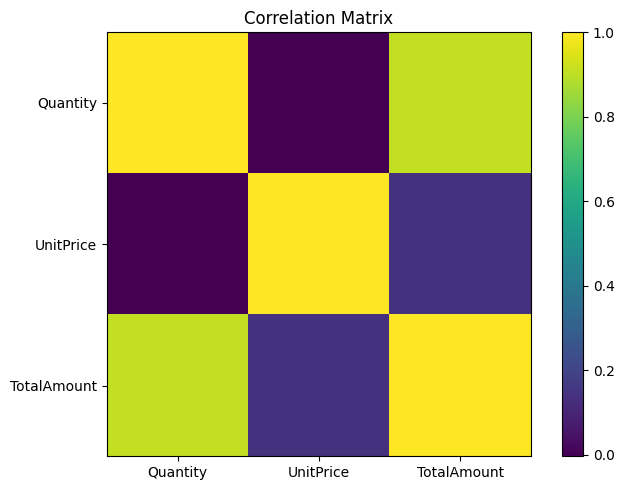


========== KEY EDA INSIGHTS ==========
Total Sales: 10,642,110.80
Average Transaction Amount: 20.28
Median Transaction Amount: 9.92
Highest Sales Country: United Kingdom (9,001,744.09)
Top Product by Sales: DOTCOM POSTAGE (206,248.77)
Top Product by Quantity: PAPER CRAFT , LITTLE BIRDIE (80,995 units)
Highest Spending Customer: 14646.0 (280,206.02)


In [122]:
# ============================================
# YuvaIntern - Week 2
# Exploratory Data Analysis & Visualization
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Make sure InvoiceDate is datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# --------------------------------------------
# 1. DESCRIPTIVE STATISTICS
# --------------------------------------------
print("DESCRIPTIVE STATISTICS")
display(df_clean.describe())

# --------------------------------------------
# 2. SALES BY COUNTRY
# --------------------------------------------
country_sales = (
    df_clean.groupby('Country')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP 10 COUNTRIES BY TOTAL SALES")
display(country_sales.head(10))

plt.figure(figsize=(10, 6))
country_sales.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 3. MONTHLY SALES TREND
# --------------------------------------------
monthly_sales = (
    df_clean.set_index('InvoiceDate')
    .resample('ME')['TotalAmount']
    .sum()
)

print("\nMONTHLY SALES")
display(monthly_sales)

plt.figure(figsize=(12, 6))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --------------------------------------------
# 4. TOP 10 PRODUCTS BY SALES
# --------------------------------------------
product_sales = (
    df_clean.groupby('Description')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP 10 PRODUCTS BY TOTAL SALES")
display(product_sales.head(10))

plt.figure(figsize=(10, 6))
product_sales.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 5. TOP 10 PRODUCTS BY QUANTITY
# --------------------------------------------
product_quantity = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP 10 PRODUCTS BY QUANTITY SOLD")
display(product_quantity.head(10))

plt.figure(figsize=(10, 6))
product_quantity.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 6. TOTAL AMOUNT DISTRIBUTION
# --------------------------------------------
plt.figure(figsize=(10, 6))
plt.hist(df_clean['TotalAmount'], bins=50)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 7. QUANTITY DISTRIBUTION
# --------------------------------------------
plt.figure(figsize=(10, 6))
plt.hist(df_clean['Quantity'], bins=50)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 8. CUSTOMER SPENDING ANALYSIS
# --------------------------------------------
customer_sales = (
    df_clean.dropna(subset=['CustomerID'])
    .groupby('CustomerID')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP 10 CUSTOMERS BY TOTAL SPENDING")
display(customer_sales.head(10))

plt.figure(figsize=(10, 6))
customer_sales.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 9. CORRELATION ANALYSIS
# --------------------------------------------
correlation = df_clean[
    ['Quantity', 'UnitPrice', 'TotalAmount']
].corr()

print("\nCORRELATION MATRIX")
display(correlation)

plt.figure(figsize=(7, 5))
plt.imshow(correlation, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 10. KEY EDA SUMMARY
# --------------------------------------------
print("\n========== KEY EDA INSIGHTS ==========")

print(f"Total Sales: {df_clean['TotalAmount'].sum():,.2f}")
print(f"Average Transaction Amount: {df_clean['TotalAmount'].mean():,.2f}")
print(f"Median Transaction Amount: {df_clean['TotalAmount'].median():,.2f}")

print(
    f"Highest Sales Country: "
    f"{country_sales.index[0]} "
    f"({country_sales.iloc[0]:,.2f})"
)

print(
    f"Top Product by Sales: "
    f"{product_sales.index[0]} "
    f"({product_sales.iloc[0]:,.2f})"
)

print(
    f"Top Product by Quantity: "
    f"{product_quantity.index[0]} "
    f"({product_quantity.iloc[0]:,.0f} units)"
)

print(
    f"Highest Spending Customer: "
    f"{customer_sales.index[0]} "
    f"({customer_sales.iloc[0]:,.2f})"
)